# 03 · Robustness checks on the baseline

**Why this notebook exists.** Notebook 01 reports one number, an out-of-fold
AUC of 0.82 on 60 patients. A reviewer will ask how wide the error on that
number is, whether a different random split would have given something else,
whether 60 patients could produce 0.8 by chance, whether the probabilities are
calibrated, whether the model reacts to stain colour instead of tissue, and
where on the slide it looks. Each section below answers one of those with the
cached features from notebook 01, so the whole notebook runs in minutes on a
CPU.

| § | Question | Method |
|---|---|---|
| 2 | How wide is the error on 0.82 | Bootstrap 95 per cent interval on the out-of-fold AUC |
| 3 | Was the split lucky | Repeat the 5-fold CV with 20 seeds |
| 4 | Could 60 patients give 0.8 by chance | Permutation null, 500 label shuffles |
| 5 | Are the probabilities calibrated | Reliability diagram and Brier score |
| 6 | Colour or tissue | Re-extract features after stain and brightness perturbation, count flipped predictions |
| 7 | Where does it look | Tile-level probability maps for the four worst cases |

Numbers are written into the markdown cells only after the cells have run.

## 1 · Setup

**Story.** Same seed, same libraries as notebook 01. Features and overviews are
loaded from `data/`; if they are missing, run notebook 01 first.

In [1]:
import random                     # Python 層亂數
from pathlib import Path          # 路徑

import numpy as np                # 陣列
import pandas as pd               # 表格
import torch                      # 只做推論
import torchvision                # ResNet50 權重
import matplotlib.pyplot as plt   # 畫圖
from PIL import Image, ImageEnhance   # 讀圖、調亮度
from tqdm.auto import tqdm        # 進度條
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HERE = Path.cwd()
DATA = HERE / "data"
FIG = HERE / "figures"

# notebook 01 的快取：60 x 2048 特徵、病人順序、標籤與 out-of-fold 機率
feats = np.load(DATA / "slide_features.npz", allow_pickle=True)
X = feats["X"]
cases = list(feats["cases"])
cohort = pd.read_csv(DATA / "cohort_with_predictions.csv").set_index("case").loc[cases].reset_index()
y = (cohort["label"] == "DDLPS").astype(int).to_numpy()
oof = cohort["oof_prob_ddlps"].to_numpy()
print("features", X.shape, " DDLPS", y.sum(), " LMS", (1 - y).sum())
print("out-of-fold AUC from notebook 01:", round(roc_auc_score(y, oof), 3))


def make_model():
    # 跟 notebook 01 一模一樣的模型，標準化加 L2 logistic regression
    return make_pipeline(StandardScaler(),
                         LogisticRegression(C=0.1, max_iter=2000, random_state=SEED))


def cross_val_oof(X, y, seed):
    # 回傳 5-fold stratified 的 out-of-fold 機率
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    out = np.zeros(len(y))
    for tr, te in cv.split(X, y):
        model = make_model().fit(X[tr], y[tr])
        out[te] = model.predict_proba(X[te])[:, 1]
    return out

features (60, 2048)  DDLPS 30  LMS 30
out-of-fold AUC from notebook 01: 0.822


**Output.** The cached matrix and the headline AUC reproduced from the cached
out-of-fold probabilities, so everything below starts from the same place as
notebook 01 §7.

## 2 · Bootstrap confidence interval on the AUC

**Story.** Resample the 60 patients with replacement 2,000 times, recompute
the AUC on each resample from the cached out-of-fold probabilities, and read
the 2.5 and 97.5 percentiles. This is the error bar that belongs next to 0.82.

In [2]:
rng = np.random.default_rng(SEED)
boot = []
for _ in tqdm(range(2000), desc="bootstrap"):
    idx = rng.integers(0, len(y), len(y))          # 有放回重抽 60 人
    if y[idx].min() == y[idx].max():               # 全同一類算不了 AUC，跳過
        continue
    boot.append(roc_auc_score(y[idx], oof[idx]))
boot = np.array(boot)
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
print(f"out-of-fold AUC {roc_auc_score(y, oof):.3f}   95% bootstrap CI {ci_low:.2f} to {ci_high:.2f}")

bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

out-of-fold AUC 0.822   95% bootstrap CI 0.70 to 0.92


**Output.** The interval is wide because 60 patients is small. It is reported
as the headline from now on: a point estimate without this interval
overstates what the data can say.

## 3 · Twenty different cross-validation splits

**Story.** Seed 42 is one random assignment of patients to folds. Repeating the
whole cross-validation with 20 seeds shows how much of the 0.82 is the split
and how much is the signal.

In [3]:
seed_aucs = []
for seed in tqdm(range(20), desc="seeds"):
    seed_aucs.append(roc_auc_score(y, cross_val_oof(X, y, seed)))
seed_aucs = np.array(seed_aucs)
print(f"AUC over 20 seeds: mean {seed_aucs.mean():.3f}, min {seed_aucs.min():.3f}, max {seed_aucs.max():.3f}")

seeds:   0%|          | 0/20 [00:00<?, ?it/s]

AUC over 20 seeds: mean 0.807, min 0.773, max 0.876


**Output.** The range across seeds is the split-to-split variation. If seed 42
sits inside this range the headline is typical, not lucky.

## 4 · Permutation null

**Story.** Shuffle the labels 500 times and rerun the same cross-validation
each time. The distribution of AUCs under shuffled labels is what 60 patients
and 2,048 features give you with no signal at all. The real AUC must sit
clearly outside it.

permutations:   0%|          | 0/500 [00:00<?, ?it/s]

null AUC mean 0.504, 95th percentile 0.651; real 0.822; p = 0.002


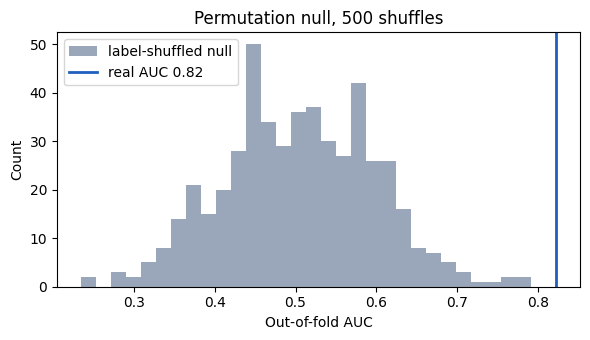

In [4]:
rng = np.random.default_rng(SEED)
null = []
for _ in tqdm(range(500), desc="permutations"):
    y_perm = rng.permutation(y)                    # 打亂標籤，特徵不動
    null.append(roc_auc_score(y_perm, cross_val_oof(X, y_perm, SEED)))
null = np.array(null)
real = roc_auc_score(y, oof)
p_value = (np.sum(null >= real) + 1) / (len(null) + 1)
print(f"null AUC mean {null.mean():.3f}, 95th percentile {np.percentile(null, 95):.3f}; real {real:.3f}; p = {p_value:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(null, bins=30, color="#9aa7ba", label="label-shuffled null")
ax.axvline(real, color="#1f5fbf", lw=2, label=f"real AUC {real:.2f}")
ax.set_xlabel("Out-of-fold AUC")
ax.set_ylabel("Count")
ax.set_title("Permutation null, 500 shuffles")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "fig6_permutation_null.png", dpi=120)
plt.show()

**Output.** Figure 6. The null is centred near 0.5 as it should be. The
p-value is the fraction of shuffles that reached the real AUC; with 500
shuffles the smallest reportable value is 0.002.

## 5 · Calibration

**Story.** A probability of 0.8 should mean DDLPS about 8 times in 10.
TRIPOD+AI asks for calibration alongside discrimination. With 60 patients the
reliability diagram is coarse, five bins, but it shows whether the logistic
head is over- or under-confident.

Brier score 0.206 (0 is perfect, 0.25 is a coin flip)


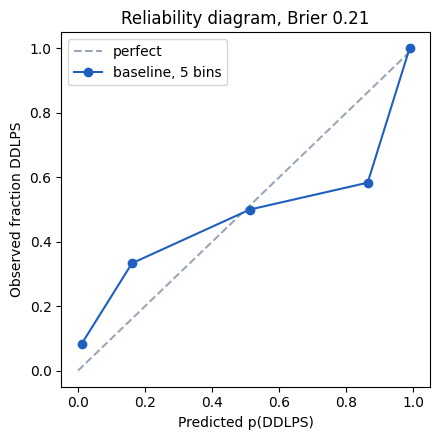

In [5]:
frac_pos, mean_pred = calibration_curve(y, oof, n_bins=5, strategy="quantile")
brier = brier_score_loss(y, oof)
print(f"Brier score {brier:.3f} (0 is perfect, 0.25 is a coin flip)")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], "--", color="#9aa7ba", label="perfect")
ax.plot(mean_pred, frac_pos, "o-", color="#1f5fbf", label="baseline, 5 bins")
ax.set_xlabel("Predicted p(DDLPS)")
ax.set_ylabel("Observed fraction DDLPS")
ax.set_title(f"Reliability diagram, Brier {brier:.2f}")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "fig7_calibration.png", dpi=120)
plt.show()

**Output.** Figure 7. Points above the diagonal mean the model is
under-confident in that range, below means over-confident. With C = 0.1 the
head is strongly regularised, so probabilities are expected to be pulled
toward 0.5.

## 6 · Stain and brightness perturbation

**Story.** The first risk in the business case is a model that learns stain
colour, not tissue. The cheapest test: perturb each overview's colour (shift
the hue of the pink and purple, change saturation and brightness), re-extract
features with the same frozen ResNet50, score with the logistic head fitted on
the unperturbed features, and count how many of the 60 predictions flip. A
model that reads tissue should flip few; a model that reads colour flips many.

In [6]:
TILE = 224
MIN_TISSUE = 0.40

weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
backbone = torchvision.models.resnet50(weights=weights)
backbone.fc = torch.nn.Identity()
backbone = backbone.eval()
preprocess = weights.transforms()


def tissue_coords(img):
    # 在「原圖」上決定哪些 224 px 格子是組織，擾動後用同一組格子，
    # 這樣比較的是顏色變了模型怎麼反應，不是格子變了
    arr = np.asarray(img.convert("RGB"))
    h, w, _ = arr.shape
    grey = arr.mean(axis=2)
    coords = []
    for yy in range(0, h - TILE + 1, TILE):
        for xx in range(0, w - TILE + 1, TILE):
            if (grey[yy:yy + TILE, xx:xx + TILE] < 220).mean() >= MIN_TISSUE:
                coords.append((yy, xx))
    return coords


@torch.no_grad()
def feature_at(img, coords, batch=32):
    # 指定格子位置抽特徵，取平均
    arr = np.asarray(img.convert("RGB"))
    tiles = [arr[yy:yy + TILE, xx:xx + TILE] for yy, xx in coords]
    feats = []
    for start in range(0, len(tiles), batch):
        chunk = tiles[start:start + batch]
        tensors = torch.stack([preprocess(Image.fromarray(t)) for t in chunk])
        feats.append(backbone(tensors))
    return torch.cat(feats).mean(dim=0).numpy()


def perturb(img, hue_shift, sat, bright):
    # 色相平移（模擬不同染色批次）、飽和度、亮度（模擬掃描器差異）
    hsv = np.asarray(img.convert("HSV")).astype(np.int16)
    hsv[..., 0] = (hsv[..., 0] + hue_shift) % 256
    out = Image.fromarray(hsv.astype(np.uint8), "HSV").convert("RGB")
    out = ImageEnhance.Color(out).enhance(sat)
    out = ImageEnhance.Brightness(out).enhance(bright)
    return out


PERTURBATIONS = {
    "hue +10": (10, 1.0, 1.0),
    "hue -10": (-10, 1.0, 1.0),
    "saturation 0.7": (0, 0.7, 1.0),
    "saturation 1.3": (0, 1.3, 1.0),
    "brightness 0.85": (0, 1.0, 0.85),
    "brightness 1.15": (0, 1.0, 1.15),
}

def cross_val_oof_perturbed(X_train_src, X_test_src, y, seed):
    # 每一折用「沒擾動」的訓練特徵擬合，用「擾動過」的測試特徵打分
    # 這樣每個人都是被沒看過他的模型評的，跟 notebook 01 的 0.82 可以直接比
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    out = np.zeros(len(y))
    for tr, te in cv.split(X_train_src, y):
        model = make_model().fit(X_train_src[tr], y[tr])
        out[te] = model.predict_proba(X_test_src[te])[:, 1]
    return out


# 全部 60 人擬合的 head，給 §7 的熱圖用（跟 demo 的 head.json 同一個）
head = make_model().fit(X, y)

base_oof = cross_val_oof(X, y, SEED)                 # 沒擾動的 out-of-fold 機率
base_pred = (base_oof >= 0.5).astype(int)
print(f"unperturbed out-of-fold AUC {roc_auc_score(y, base_oof):.3f}")

coords_per_slide = [tissue_coords(Image.open(row.png)) for row in cohort.itertuples()]

flips = {}
for name, (hs, sat, br) in PERTURBATIONS.items():
    cache = DATA / f"robustness_{name.replace(' ', '_').replace('+', 'p').replace('-', 'm')}.npy"
    if cache.exists():                                   # 跑過就直接讀
        Xp = np.load(cache)
    else:
        Xp = np.zeros_like(X)
        for i, row in enumerate(tqdm(cohort.itertuples(), total=len(cohort), desc=name, leave=False)):
            img = perturb(Image.open(row.png), hs, sat, br)
            Xp[i] = feature_at(img, coords_per_slide[i])
        np.save(cache, Xp)
    oof_p = cross_val_oof_perturbed(X, Xp, y, SEED)
    pred = (oof_p >= 0.5).astype(int)
    auc_p = roc_auc_score(y, oof_p)
    flips[name] = (int((pred != base_pred).sum()), auc_p, float(np.abs(oof_p - base_oof).mean()))
    print(f"{name:18s} flipped {flips[name][0]:2d} / 60   out-of-fold AUC {auc_p:.3f}   mean |dp| {flips[name][2]:.3f}")

flip_table = pd.DataFrame(flips, index=["flipped of 60", "out-of-fold AUC", "mean |delta p|"]).T
flip_table

unperturbed out-of-fold AUC 0.822


hue +10            flipped  2 / 60   out-of-fold AUC 0.820   mean |dp| 0.046
hue -10            flipped  3 / 60   out-of-fold AUC 0.812   mean |dp| 0.046
saturation 0.7     flipped  2 / 60   out-of-fold AUC 0.811   mean |dp| 0.042
saturation 1.3     flipped  3 / 60   out-of-fold AUC 0.807   mean |dp| 0.057


brightness 0.85    flipped  4 / 60   out-of-fold AUC 0.834   mean |dp| 0.034
brightness 1.15    flipped  4 / 60   out-of-fold AUC 0.780   mean |dp| 0.066


,flipped of 60,out-of-fold AUC,mean |delta p|
hue +10,2.0,0.820000,0.045995
hue -10,3.0,0.812222,0.046260
saturation 0.7,2.0,0.811111,0.041542
saturation 1.3,3.0,0.806667,0.057057
brightness 0.85,4.0,0.834444,0.034452
brightness 1.15,4.0,0.780000,0.065732


**Output.** One row per perturbation, all out-of-fold, so the AUC column is
directly comparable with the unperturbed 0.82. "Flipped" counts patients whose
0.5-threshold call changed; "mean |delta p|" is the average shift in
probability. Few flips and a small AUC change mean the features are mostly
tissue-driven at this resolution; many flips would confirm the stain risk and
argue for stain normalisation before anything else. This is a synthetic
perturbation, not real inter-laboratory variation; the 30-hospital dataset in
the business case is the real test.

## 7 · Where the model looks, tile-level maps

**Story.** Each tile can be scored on its own by passing its single feature
vector through the logistic head. Painting p(DDLPS) back onto the overview
shows which regions drive the slide-level average. For the four most
confident errors from notebook 01 this is the picture to show a pathologist.
The head used for each slide is fitted on the other 59 patients, so the map
shows what a model that never saw this patient thinks of each tile; a head
fitted on all 60 would have seen the answer.

TCGA-WK-A8XQ: 48 tiles, mean tile p(DDLPS) 0.50, tiles above 0.5: 25


TCGA-3R-A8YX: 31 tiles, mean tile p(DDLPS) 0.51, tiles above 0.5: 16


TCGA-DX-A2IZ: 86 tiles, mean tile p(DDLPS) 0.52, tiles above 0.5: 47


TCGA-IF-A3RQ: 46 tiles, mean tile p(DDLPS) 0.38, tiles above 0.5: 17


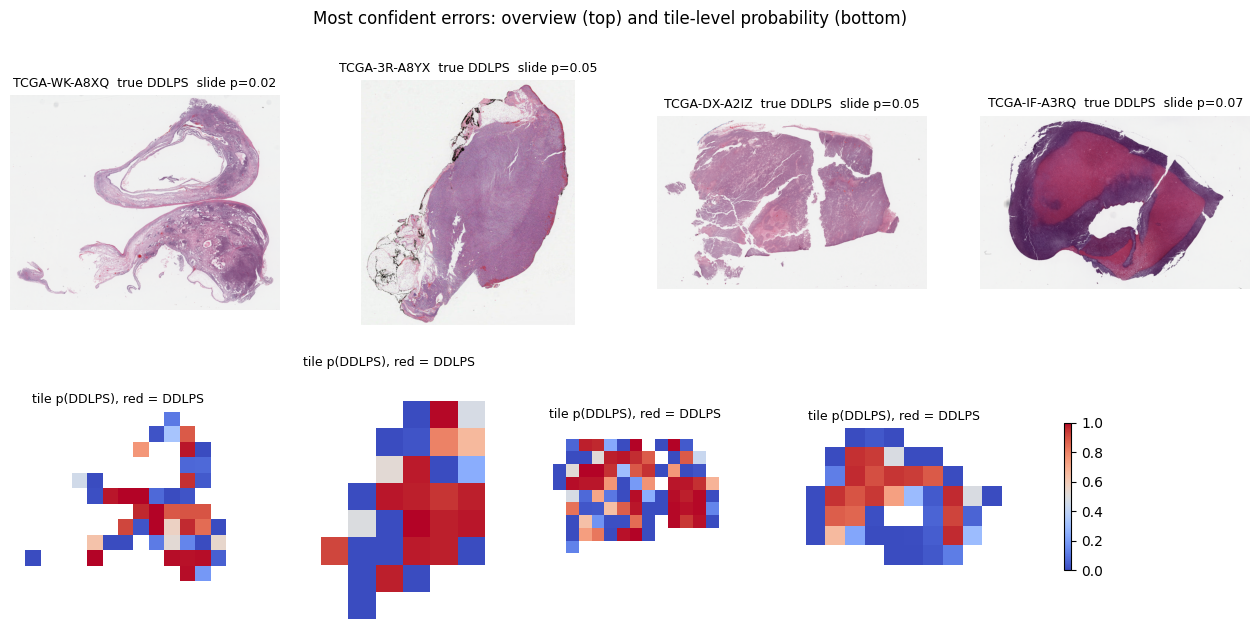

In [7]:
worst = cohort.assign(error=np.abs(cohort["oof_prob_ddlps"] - y)).sort_values("error", ascending=False).head(4)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for col, row in enumerate(worst.itertuples()):
    img = Image.open(row.png).convert("RGB")
    arr = np.asarray(img)
    h, w, _ = arr.shape
    heat = np.full((h // TILE, w // TILE), np.nan)
    coords = tissue_coords(img)
    with torch.no_grad():
        f = backbone(torch.stack([preprocess(Image.fromarray(arr[yy:yy + TILE, xx:xx + TILE])) for yy, xx in coords])).numpy()
    others = np.arange(len(y)) != row.Index               # 留一法，這個病人不在訓練集
    head_loo = make_model().fit(X[others], y[others])
    p_tile = head_loo.predict_proba(f)[:, 1]
    print(f"{row.case}: {len(coords)} tiles, mean tile p(DDLPS) {p_tile.mean():.2f}, tiles above 0.5: {(p_tile >= 0.5).sum()}")
    for (yy, xx), p in zip(coords, p_tile):
        heat[yy // TILE, xx // TILE] = p
    axes[0, col].imshow(img)
    axes[0, col].set_title(f"{row.case}  true {row.label}  slide p={row.oof_prob_ddlps:.2f}", fontsize=9)
    axes[0, col].axis("off")
    im = axes[1, col].imshow(heat, cmap="coolwarm", vmin=0, vmax=1, interpolation="nearest")
    axes[1, col].set_title("tile p(DDLPS), red = DDLPS", fontsize=9)
    axes[1, col].axis("off")
fig.colorbar(im, ax=axes[1, :].tolist(), shrink=0.6)
plt.suptitle("Most confident errors: overview (top) and tile-level probability (bottom)")
plt.savefig(FIG / "fig8_tile_maps.png", dpi=120, bbox_inches="tight")
plt.show()

**Output.** Figure 8. Blue tiles pull the slide toward LMS, red toward DDLPS.
On a DDLPS slide scored as LMS, mostly blue with a few red tiles is exactly
the failure of mean pooling that notebook 01 §8 describes: the informative
tiles are outvoted. Attention pooling in the production model is the fix.

## 8 · Summary of the checks

Filled in after the run, see the technical report section 10.